In [ ]:
import sys
import os
import numpy as np
import matplotlib.pylab as plt
import uproot
import awkward as ak
import seaborn
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.stats import skew

# define the path to mother directory F-CAL-TB to use files in it
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
os.chdir(project_root)

import RA_funcs as rf
import Scope_funcs as sf


imports work
imports work


/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/RA_funcs.py:161: SyntaxWarning: invalid escape sequence '\T'
  file_name = f"TB_FIRE\TB_reco\TB_FIRE_{run_number}_raw_reco.root"
/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/RA_funcs.py:198: SyntaxWarning: invalid escape sequence '\T'
  file_name = f"TB_FIRE\TB_reco\TB_FIRE_{run_number}_raw_reco.root"


In [2]:
# hit_data_1093 = rf.get_ROOT_data_zip_RECO(1093)
# hit_data_1088 = rf.get_ROOT_data_zip_RECO(1088)
# hit_data_scope_1093_reco = sf.DUT_TELE_merge(1093)
hit_data_scope_1093_unfiltered = sf.get_ROOT_data_zip_Aligned(1093, return_TLU=False)

In [4]:
# filter chi2
def filter_chi2_scope_data(hit_data_scope, lower_chi2_bound, upper_chi2_bound):
    mask_lower = hit_data_scope.tele.chired > lower_chi2_bound
    mask_upper = hit_data_scope.tele.chired < upper_chi2_bound
    filtered_data = hit_data_scope[ak.flatten(mask_lower) & ak.flatten(mask_upper)]
    filtered_data_clean = filtered_data[ak.num(filtered_data.tele) > 0]
    return filtered_data_clean

In [5]:
hit_data_scope_1093 = filter_chi2_scope_data(hit_data_scope_1093_unfiltered, 0.1, 3)

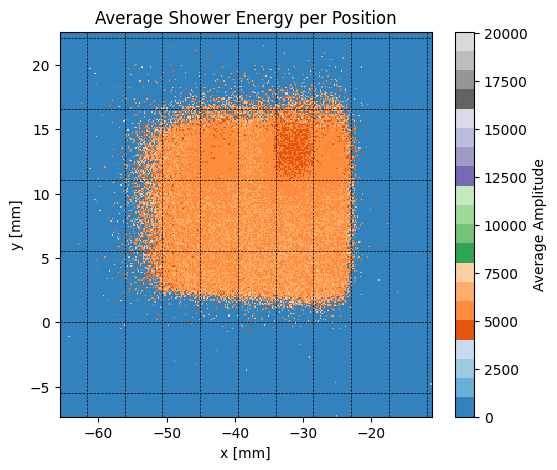

In [10]:
sf.avg_energy_scope_colormap(hit_data_scope_1093)


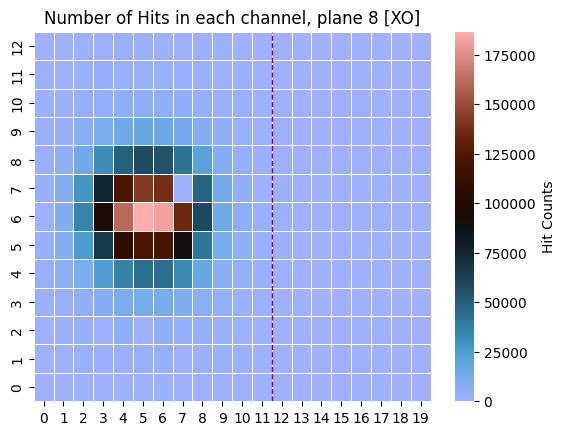

In [8]:
rf.hits_amount_colormap_single_plane(hit_data_scope_1093.hits,8)

<span style="font-family: Comic Sans MS; font-size:25px; color:orange">

PAD RECONSTRUCTION - Neuron Network

In [ ]:
# missions

# - normalization of x,y pad

#  sample only 100k events per pad

# sombine and shuffle data from all pads

# train the data and save the model

In [5]:
# build a function for neuron model training

In [11]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
import torch.nn as nn
import torch.optim as optim
import glob

In [ ]:
# create the data for the model

def get_data_for_pad_correction_NN(scope_data, plane, pad):
    
    # amount of events
    N = len(scope_data)
    
    # previous plane energy in the same pad
    previous_plane = scope_data.hits[scope_data.hits.plane == plane - 1]
    prev_plane_same_ch = previous_plane[previous_plane.ch == pad]
    prev_plane_amp = ak.where(ak.num(prev_plane_same_ch.amp) != 1, [[0]], prev_plane_same_ch.amp)

    # next plane energy in the same pad
    next_plane = scope_data.hits[scope_data.hits.plane == plane + 1]
    next_plane_same_ch = next_plane[next_plane.ch == pad]
    next_plane_amp = ak.where(ak.num(next_plane_same_ch.amp) != 1, [[0]], next_plane_same_ch.amp)

    # surroundings pads energy in the same plane (+- 1, 19,20,21)
    next_plane = scope_data.hits[scope_data.hits.plane == plane]
    pad_minus_1a = next_plane[next_plane.ch == pad - 1]
    pad_minus_1 = ak.where(ak.num(pad_minus_1a.amp) != 1, [[0]], next_plane_same_ch.amp)

    next_plane = scope_data.hits[scope_data.hits.plane == plane]
    pad_plus_1a = next_plane[next_plane.ch == pad + 1]
    pad_plus_1 = ak.where(ak.num(pad_plus_1a.amp) != 1, [[0]], next_plane_same_ch.amp)

    # output = amplitude of the wanted pad
    plane_data = scope_data.hits[scope_data.hits.plane == plane]
    plane_pad_data = plane_data[plane_data.ch == pad]
    current_pad_amp = ak.where(ak.num(plane_pad_data.amp) != 1, [[0]], plane_pad_data.amp)

    # convert data to numpy


    prev_amp_np = ak.to_numpy(prev_plane_amp).astype(np.float32)
    next_amp_np = ak.to_numpy(next_plane_amp).astype(np.float32)




    y_np = ak.to_numpy(current_pad_amp).astype(np.float32)

    # group inputs and shape outputs such that everything is in the same length
    X = np.column_stack([ prev_amp_np, next_amp_np]).astype(np.float32)
    y = y_np.reshape(-1, 1).astype(np.float32)

    X_t = torch.from_numpy(X)
    y_t = torch.from_numpy(y)

    return X_t, y_t


In [52]:

def _amp_for(scope_data, plane, ch, N):
    """Return (N,) float32 array of amplitude for a given (plane, ch), 0 if not exactly 1 hit."""
    hits = scope_data.hits
    sel = hits[(hits.plane == plane) & (hits.ch == ch)]
    amp = ak.where(ak.num(sel.amp) != 1, [[0]], sel.amp)   # shape (N, 1) awkward
    arr = ak.to_numpy(amp).astype(np.float32).reshape(N)   # -> (N,)
    return arr

def get_data_for_pad_correction_NN(scope_data, plane, pad):
    N = len(scope_data)

    # ---- choose your 10 inputs here ----
    # Example set of 10 features:
    feats = [
        _amp_for(scope_data, plane-1, pad,    N),  # prev same pad
        _amp_for(scope_data, plane+1, pad,    N),  # next same pad
        _amp_for(scope_data, plane,   pad-1,  N),  # left
        _amp_for(scope_data, plane,   pad+1,  N),  # right
        _amp_for(scope_data, plane,   pad-19, N),
        _amp_for(scope_data, plane,   pad-20, N), # down
        _amp_for(scope_data, plane,   pad-21, N),
        _amp_for(scope_data, plane,   pad+19, N),
        _amp_for(scope_data, plane,   pad+20, N), #up
        _amp_for(scope_data, plane,   pad+21, N),
        np.full(N,plane)

    ]

    X = np.column_stack(feats).astype(np.float32)          # (N, 10)

    # output: current pad amplitude
    y = _amp_for(scope_data, plane, pad, N).astype(np.float32).reshape(N, 1)  # (N, 1)

    return torch.from_numpy(X), torch.from_numpy(y)


In [53]:
# get traing data for many pads and planes and saves them externally
# base pads for training (taking all planes except from 0 and 8 because they dont have prev and next planes)
pads_for_training = [125,143,107]
# create torch arrays of inputs and outputs
X_t_list = []
y_t_list = []

import os
os.makedirs("training_data_neighbors", exist_ok=True)

# Following pads
for plane in range(1,7):
    for pad in pads_for_training:

        # create the torch arrays for input and output for the current pad
        X_t_pad, y_t_pad = get_data_for_pad_correction_NN(hit_data_scope_1093,plane,pad)

        # make sure Im saving floats 32 and not 64
        X_t_pad = X_t_pad.float()
        y_t_pad = y_t_pad.float()

        # # add the pad torch array to the list
        # X_t_list.append(X_t_pad)
        # y_t_list.append(y_t_pad)
        # print("plane", plane, "pad", pad, "finished")

        torch.save({"X": X_t_pad, "y": y_t_pad}, f"training_data_neighbors/plane{plane}_pad{pad}.pt")
        print(f"plane {plane}, pad {pad}: saved {len(y_t_pad)} events")

# # keep the pad data on the main array
# X_t = torch.cat(X_t_list, dim=0)
# y_t = torch.cat(y_t_list, dim=0)



plane 1, pad 125: saved 363869 events
plane 1, pad 143: saved 363869 events
plane 1, pad 107: saved 363869 events
plane 2, pad 125: saved 363869 events
plane 2, pad 143: saved 363869 events
plane 2, pad 107: saved 363869 events
plane 3, pad 125: saved 363869 events
plane 3, pad 143: saved 363869 events
plane 3, pad 107: saved 363869 events
plane 4, pad 125: saved 363869 events
plane 4, pad 143: saved 363869 events
plane 4, pad 107: saved 363869 events
plane 5, pad 125: saved 363869 events
plane 5, pad 143: saved 363869 events
plane 5, pad 107: saved 363869 events
plane 6, pad 125: saved 363869 events
plane 6, pad 143: saved 363869 events
plane 6, pad 107: saved 363869 events


In [85]:
# convert the saved data to torch arrays
files = glob.glob("training_data_neighbors/*.pt")   # all your saved pad files

X_t_list, Y_t_list = [], []
for f in files[0:3]:
    d = torch.load(f, map_location="cpu")   # {"X": ..., "y": ...}
    X_t_list.append(d["X"])
    Y_t_list.append(d["y"])

X_t = torch.cat(X_t_list, dim=0)
y_t = torch.cat(Y_t_list, dim=0)

print("X_t:", X_t.shape, X_t.dtype)
print("y_t:", y_t.shape, y_t.dtype)


X_t: torch.Size([1091607, 11]) torch.float32
y_t: torch.Size([1091607, 1]) torch.float32


In [86]:
print(torch.isnan(X_t).any(), torch.isinf(X_t).any())
print(torch.isnan(y_t).any(), torch.isinf(y_t).any())


tensor(False) tensor(False)
tensor(False) tensor(False)


In [87]:
# create loaders

# create the input-output data
dataset = TensorDataset(X_t, y_t)

N = len(dataset)

g = torch.Generator().manual_seed(42)

# 2) split kept half into train/val
train_size = int(0.8 * N)
val_size = N - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=g)

# 3) compute normalization stats on TRAIN ONLY
X_mean = X_t.mean(dim=0, keepdim=True)
X_std  = X_t.std(dim=0, keepdim=True)
X_std  = torch.where(X_std < 1e-6, torch.ones_like(X_std), X_std)

# 4) normalize ALL X using train stats
X_tn = (X_t - X_mean) / X_std

# 5) rebuild normalized dataset + normalized subsets (using global indices)
dataset_n = TensorDataset(X_tn, y_t)

# 6) loaders (use the normalized subsets!)
batch_size = 1026
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


In [88]:
# get the evaluation outputs
ys = []
for i in range(len(val_ds)):
    _, y = val_ds[i]
    ys.append(y)

y_val = torch.stack(ys)   # shape: [N, 1] (or [N] depending on your dataset)

In [89]:
# calculate a baseline mse loss using the mean as predicted values
y_mean = y_val.mean()
baseline_mse = ((y_val - y_mean) ** 2).mean()

print("Baseline MSE:", float(baseline_mse))

Baseline MSE: 26379.025390625


In [90]:
# define the neuron model
inputs = 11
hidden_size = 8
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inputs, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        return self.net(x)

model = Net()

In [91]:
# loss function and optimization
mae_fn = torch.nn.L1Loss() # Average difference
loss_fn = nn.MSELoss() # RMS deifference
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [92]:
# evaluation helper
def eval_loss(model, loader):
    model.eval()
    total = 0.0
    total_mae = 0.0
    count = 0

    # calculate loss values for each batch
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)

            # MAE loss in original space
            loss_mae = mae_fn(pred, yb)


            total += loss.item() * xb.size(0)
            total_mae += loss_mae.item() * xb.size(0)
            count += xb.size(0)
    
    # calculate the loss function values for the entire data
    mse = total / count
    mae = total_mae / count


    return  mse, mae


In [94]:
# training loop
epochs = 20

for epoch in range(1, epochs + 1):
    model.train()
    total = 0.0
    count = 0

    # run on the batchs in the training data
    for xb, yb in train_loader:
        
        # change outputs to logarithms to reduce outliers
        pred = model(xb)
        loss = loss_fn(pred, yb)

        # perform backpropagation to optimize the system and minimize loss function
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # calculate the total mse
        total += loss.item() * xb.size(0)
        count += xb.size(0)

    train_mse = total / count
    val_mse, val_mae = eval_loss(model, val_loader) #check the results on the evaluation data


    print(f"Epoch {epoch:02d} | train MSE: {train_mse:.6f} | val MSE: {val_mse:.6f} | val MAE: {val_mae:.6f}")

Epoch 01 | train MSE: 6338.980403 | val MSE: 6237.408683 | val MAE: 40.136935
Epoch 02 | train MSE: 6328.341890 | val MSE: 6209.723851 | val MAE: 40.081493
Epoch 03 | train MSE: 6316.733845 | val MSE: 6205.478037 | val MAE: 39.861419
Epoch 04 | train MSE: 6311.981550 | val MSE: 6209.834004 | val MAE: 39.577880
Epoch 05 | train MSE: 6305.611771 | val MSE: 6210.007305 | val MAE: 40.904856
Epoch 06 | train MSE: 6302.448798 | val MSE: 6183.616079 | val MAE: 40.225765
Epoch 07 | train MSE: 6295.236417 | val MSE: 6188.359927 | val MAE: 40.259106
Epoch 08 | train MSE: 6292.083844 | val MSE: 6210.819519 | val MAE: 41.096744
Epoch 09 | train MSE: 6291.411249 | val MSE: 6172.506344 | val MAE: 40.260638
Epoch 10 | train MSE: 6288.211565 | val MSE: 6169.675020 | val MAE: 40.206638
Epoch 11 | train MSE: 6285.901485 | val MSE: 6167.914028 | val MAE: 40.060762
Epoch 12 | train MSE: 6282.819181 | val MSE: 6169.413875 | val MAE: 40.174039
Epoch 13 | train MSE: 6283.001085 | val MSE: 6164.035736 | val M

<span style="font-family: Comic Sans MS; font-size:25px; color:orange">

check the network on a different pad

In [31]:
# get the input parameters as arrays
pad = 126
plane = 3
hit_data = hit_data_scope_1093
N = len(hit_data)


# x,y
initial_x_126 = hit_data_scope_1093.tele.x
initial_y_126 = hit_data_scope_1093.tele.y

# previous plane
previous_plane = hit_data.hits[hit_data.hits.plane == plane - 1]
prev_plane_same_ch = previous_plane[previous_plane.ch == pad]
prev_plane_amp_126 = ak.where(ak.num(prev_plane_same_ch.amp) != 1, [[0]], prev_plane_same_ch.amp)

# next plane
next_plane = hit_data.hits[hit_data.hits.plane == plane + 1]
next_plane_same_ch = next_plane[next_plane.ch == pad]
next_plane_amp_126 = ak.where(ak.num(next_plane_same_ch.amp) != 1, [[0]], next_plane_same_ch.amp)

# plane
pad_z_126 = np.full(N,plane)


# output = amplitude of the wanted pad
plane_data = hit_data.hits[hit_data.hits.plane == plane]
plane_pad_data = plane_data[plane_data.ch == pad]
current_pad_amp_126 = ak.where(ak.num(next_plane_same_ch.amp) != 1, [[0]], next_plane_same_ch.amp)

# convert to numpy
initial_x_126_np = ak.to_numpy(initial_x_126).astype(np.float32)
initial_y_126_np = ak.to_numpy(initial_y_126).astype(np.float32)
pad_z_126_np = ak.to_numpy(pad_z_126).astype(np.float32)
prev_amp_126_np = ak.to_numpy(prev_plane_amp_126).astype(np.float32)
next_amp_126_np = ak.to_numpy(next_plane_amp_126).astype(np.float32)

y_126_np = ak.to_numpy(current_pad_amp_126).astype(np.float32)


In [35]:
# use to predict


import numpy as np
import torch

model.eval()  # important

# 1) stack your 5 arrays into shape (N, 5)
X_126 = np.column_stack([initial_x_126_np, initial_y_126_np, pad_z_126_np, prev_amp_126_np, next_amp_126_np]).astype(np.float32)
y_126 = y_126_np.reshape(-1, 1).astype(np.float32)

# 2) convert to torch tensor
X_126_t = torch.from_numpy(X_126)

# 3) normalize using the SAME mean/std from training
X_126_tn = (X_126_t - X_mean) / X_std

# 4) predict (no gradients)
with torch.no_grad():
    y_pred_t = model(X_126_tn)     # shape (N, 1)

# 5) convert to numpy (optional)
y_pred = y_pred_t.squeeze(1).cpu().numpy()  # shape (N,)
y_pred

array([ 0.13882545, -0.22839496, 75.51837   , ...,  1.6704159 ,
       -0.10399362,  0.5083204 ], shape=(440902,), dtype=float32)

In [45]:
y_126 = y_126_np.reshape(-1)
y_126

array([ 0.,  0., 77., ...,  0.,  0.,  0.], shape=(440902,), dtype=float32)

In [48]:
y_126 - y_pred

array([-0.13882545,  0.22839496,  1.4816284 , ..., -1.6704159 ,
        0.10399362, -0.5083204 ], shape=(440902,), dtype=float32)

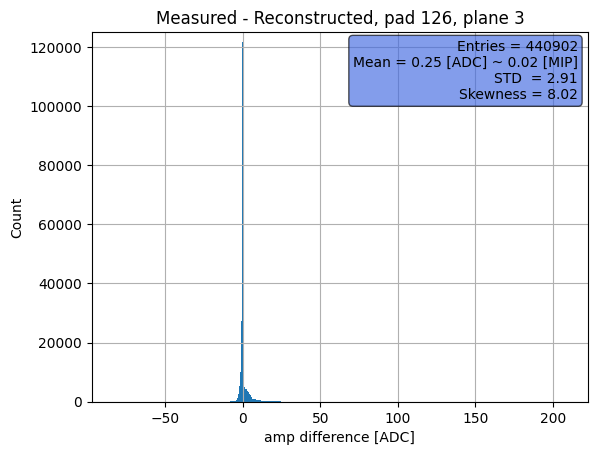

In [85]:
# plot difference between prediction and reality
diff = y_126 - y_pred

diff_mean = np.mean(diff)
diff_std  = np.std(diff, ddof=1)   # sample std
diff_skew = skew(diff, bias=False) # sample skewness
n = diff.size

fig, ax = plt.subplots()
ax.hist(diff, bins=500)
ax.set_xlabel("amp difference [ADC]")
ax.set_ylabel("Count")
ax.set_ylim(top=125000)
ax.set_title("Measured - Reconstructed, pad 126, plane 3")

stats_text = (
    f"Entries = {n}\n"
    f"Mean = {diff_mean:.2f} [ADC] ~ {diff_mean/14.5:.2f} [MIP]\n"
    f"STD  = {diff_std:.2f}\n"
    f"Skewness = {diff_skew:.2f}"
)

ax.text(
    0.98, 0.98, stats_text,
    transform=ax.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="royalblue", alpha=0.65)
)

# ax.set_yscale("log") 
ax.grid()
plt.show()
